In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

#📌 Extracción

In [277]:
datos = pd.read_json(url)
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [278]:
datos_normalizados = pd.concat([
    datos[['customerID', 'Churn']],
    pd.json_normalize(datos['customer']),
    pd.json_normalize(datos['phone']),
    pd.json_normalize(datos['internet']),
    pd.json_normalize(datos['account'])
], axis=1)

datos_normalizados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [279]:
# Verificar normalización:
columnas_esperadas = [
    'customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total'
]

faltantes = [col for col in columnas_esperadas if col not in datos_normalizados.columns]
extras    = [col for col in datos_normalizados.columns if col not in columnas_esperadas]

faltantes, extras

([], [])

In [280]:
datos_normalizados.shape, datos_normalizados.columns.tolist()

((7267, 21),
 ['customerID',
  'Churn',
  'gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'tenure',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod',
  'Charges.Monthly',
  'Charges.Total'])

In [281]:
datos_normalizados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#🔧 Transformación

## **Exploración profunda**

In [282]:
datos_normalizados.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [283]:
datos_normalizados.duplicated().sum()

np.int64(0)

In [284]:
datos_normalizados.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [285]:
# Verificar los valores únicos de cada columna categórica
columnas_categoricas = ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService',
                        'MultipleLines', 'InternetService', 'Contract',
                        'PaperlessBilling', 'PaymentMethod']

for col in columnas_categoricas:
    display(datos_normalizados[col].value_counts())

,count
Churn,
No,5174
Yes,1869
,224


,count
gender,
Male,3675
Female,3592


,count
Partner,
No,3749
Yes,3518


,count
Dependents,
No,5086
Yes,2181


,count
PhoneService,
Yes,6560
No,707


,count
MultipleLines,
No,3495
Yes,3065
No phone service,707


,count
InternetService,
Fiber optic,3198
DSL,2488
No,1581


,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


,count
PaperlessBilling,
Yes,4311
No,2956


,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


## **Modificaciones en la columna Churn**

In [286]:
# Verificación de espacios en la columna
(datos_normalizados['Churn'] == '').sum()


np.int64(224)

In [287]:
# Corrección para Churn
# Reemplazar string vacío por NaN para detectarlos correctamente

datos_normalizados['Churn'] = datos_normalizados['Churn'].replace('', np.nan)
datos_normalizados['Churn'].isnull().sum()

np.int64(224)

In [288]:
datos_normalizados.shape

(7267, 21)

In [289]:
# Se eliminaron 224 registros donde la columna 'Churn' tenía valores vacíos ("").
# Porque estos no eran nulos reales, sino strings vacíos que pandas no detecta con isnull().
# Como 'Churn' es la variable objetivo del análisis (si el cliente abandonó o no),
# imputar estos valores introduciría sesgo artificial en los resultados.
# Al representar solo el 3% del total de registros, su eliminación no afecta significativamente el análisis.
datos_normalizados.dropna(subset=['Churn'], inplace=True)
datos_normalizados.shape

(7043, 21)

## **Modificación en Charges.Total**

In [290]:
# Modificar Charges.Total, porque debe ser numerico
datos_normalizados['Charges.Total'] = pd.to_numeric(datos_normalizados['Charges.Total'], errors='coerce')
datos_normalizados[['Charges.Monthly', 'Charges.Total']].dtypes

,0
Charges.Monthly,float64
Charges.Total,float64


In [291]:
datos_normalizados['Charges.Total'].isnull().sum()

np.int64(11)

In [292]:
datos_normalizados[datos_normalizados['Charges.Total'].isnull()]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


clientes con tenure = 0 son clientes que acaban de registrarse y aún no han completado su primer mes de servicio. Por lo tanto, su cargo total real es 0

In [293]:
datos_normalizados['Charges.Total'] = datos_normalizados['Charges.Total'].fillna(0)
datos_normalizados['Charges.Total'].isnull().sum()

np.int64(0)

In [294]:
datos_normalizados.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [295]:
datos_normalizados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [296]:
datos_normalizados['Cuentas_Diarias'] = (datos_normalizados['Charges.Monthly'] / 30).round(2)
datos_normalizados['Cuentas_Diarias']

,Cuentas_Diarias
0,2.19
1,2.00
2,2.46
3,3.27
4,2.80
...,...
7262,1.84
7263,2.84
7264,1.68
7265,2.26


## **Convertir columnas Yes/No a binario (1/0):**

In [297]:
columnas_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
                     'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

datos_normalizados[columnas_binarias] = datos_normalizados[columnas_binarias].apply(
    lambda col: col.map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})
)
datos_normalizados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


##  **Estandarizar columna Churn y gender:**

In [298]:
datos_normalizados['Churn'].isnull().sum()

np.int64(0)

In [299]:
datos_normalizados['Churn'] = datos_normalizados['Churn'].map({'Yes': 1, 'No': 0})
datos_normalizados['gender'] = datos_normalizados['gender'].map({'Male': 1, 'Female': 0})
datos_normalizados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


## **Comprobar tipos de datos y renombres de columnas**

In [300]:
datos_normalizados.dtypes

,0
customerID,object
Churn,int64
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,object


In [301]:
datos_normalizados.rename(columns={
    'customerID'      : 'ID_Cliente',
    'Churn'           : 'Abandono',
    'gender'          : 'Genero',
    'SeniorCitizen'   : 'Adulto_Mayor',
    'Partner'         : 'Pareja',
    'Dependents'      : 'Dependientes',
    'tenure'          : 'Meses_Contrato',
    'PhoneService'    : 'Servicio_Telefono',
    'MultipleLines'   : 'Lineas_Multiples',
    'InternetService' : 'Servicio_Internet',
    'OnlineSecurity'  : 'Seguridad_Online',
    'OnlineBackup'    : 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport'     : 'Soporte_Tecnico',
    'StreamingTV'     : 'Streaming_TV',
    'StreamingMovies' : 'Streaming_Peliculas',
    'Contract'        : 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod'   : 'Metodo_Pago',
    'Charges.Monthly' : 'Cargos_Mensuales',
    'Charges.Total'   : 'Cargos_Totales'
}, inplace=True)
datos_normalizados.head()

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis


In [302]:
# Renombre de los datos
datos_limpios = datos_normalizados

## **Análisis Descriptivo**

Para comprender el comportamiento general de los clientes, se calculo las principales métricas estadísticas de las variables numéricas clave: meses de contrato, cargos mensuales, cargos totales y costo diario.

Estas métricas nos permiten identificar la distribución de los datos y detectar posibles patrones antes de cruzarlos con la variable de abandono.

In [303]:
datos_limpios.describe()

,Abandono,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Factura_Digital,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [304]:
columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

# describe() entrega count, mean, std, min, percentiles y max
# Se agregan mediana, asimetría y curtosis para una visión más completa de la distribución

datos_limpios[columnas_numericas].describe().T.assign(
    mediana   = datos_limpios[columnas_numericas].median(),
    asimetria = datos_limpios[columnas_numericas].skew(),
    curtosis  = datos_limpios[columnas_numericas].kurt()
)

,count,mean,std,min,25%,50%,75%,max,mediana,asimetria,curtosis
Meses_Contrato,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,29.00,0.239540,-1.387372
Cargos_Mensuales,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,70.35,-0.220524,-1.257260
Cargos_Totales,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,1394.55,0.963235,-0.228580
Cuentas_Diarias,7043.0,2.158675,1.003088,0.61,1.18,2.34,2.99,3.96,2.34,-0.220524,-1.257155


## 📊 Distribución de Evasión

Analisis de la proporción de clientes que permanecieron en la empresa versus los que se dieron de baja. Esto nos permite entender el nivel de desbalance entre ambas clases, dato fundamental antes de construir cualquier modelo predictivo.

In [305]:
# Proporción de clientes que permanecieron vs los que se dieron de baja
evasion = datos_limpios['Abandono'].value_counts()
evasion_pct = datos_limpios['Abandono'].value_counts(normalize=True).mul(100).round(2)

evasion, evasion_pct

(Abandono
 0    5174
 1    1869
 Name: count, dtype: int64,
 Abandono
 0    73.46
 1    26.54
 Name: proportion, dtype: float64)

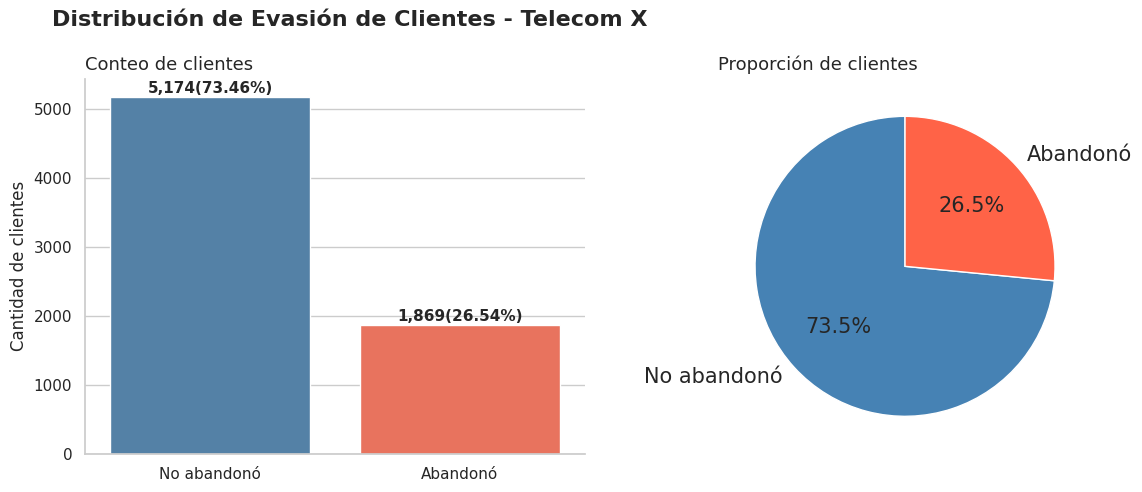

In [306]:
sns.set_theme(style='whitegrid')

evasion = datos_limpios['Abandono'].value_counts().reset_index()
evasion.columns = ['Abandono', 'Cantidad']
evasion['Porcentaje'] = (evasion['Cantidad'] / evasion['Cantidad'].sum() * 100).round(2)
evasion['Estado'] = evasion['Abandono'].map({0: 'No abandonó', 1: 'Abandonó'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Evasión de Clientes - Telecom X',
             fontsize=16, fontweight='bold', x=0.05, ha='left')

# Gráfico de barras estilizado
ax = axes[0]
bars = sns.barplot(data=evasion, x='Estado', y='Cantidad',
                   hue='Estado', palette=['steelblue', 'tomato'],
                   legend=False, ax=ax)
ax.set_title('Conteo de clientes', loc='left', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Cantidad de clientes', fontsize=12)
ax.yaxis.set_tick_params(labelsize=11)
ax.xaxis.set_tick_params(labelsize=11)
sns.despine()

# Etiquetas encima de cada barra
for i, row in evasion.iterrows():
    ax.text(i, row['Cantidad'] + 50, f"{row['Cantidad']:,}({row['Porcentaje']}%)",
            ha='center', fontsize=11, fontweight='bold')

# Gráfico circular
axes[1].pie(evasion['Cantidad'], labels=evasion['Estado'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, textprops={'fontsize': 15})
axes[1].set_title('Proporción de clientes', loc='left', fontsize=13)

plt.tight_layout()
plt.show()

## 📊 Recuento de Evasión por Variables Categóricas

Exploración de cómo se distribuye la evasión según variables categóricas como género, tipo de contrato, método de pago, entre otras. Este análisis permite identificar perfiles de clientes con mayor tendencia a cancelar el servicio, orientando acciones estratégicas para la retención.

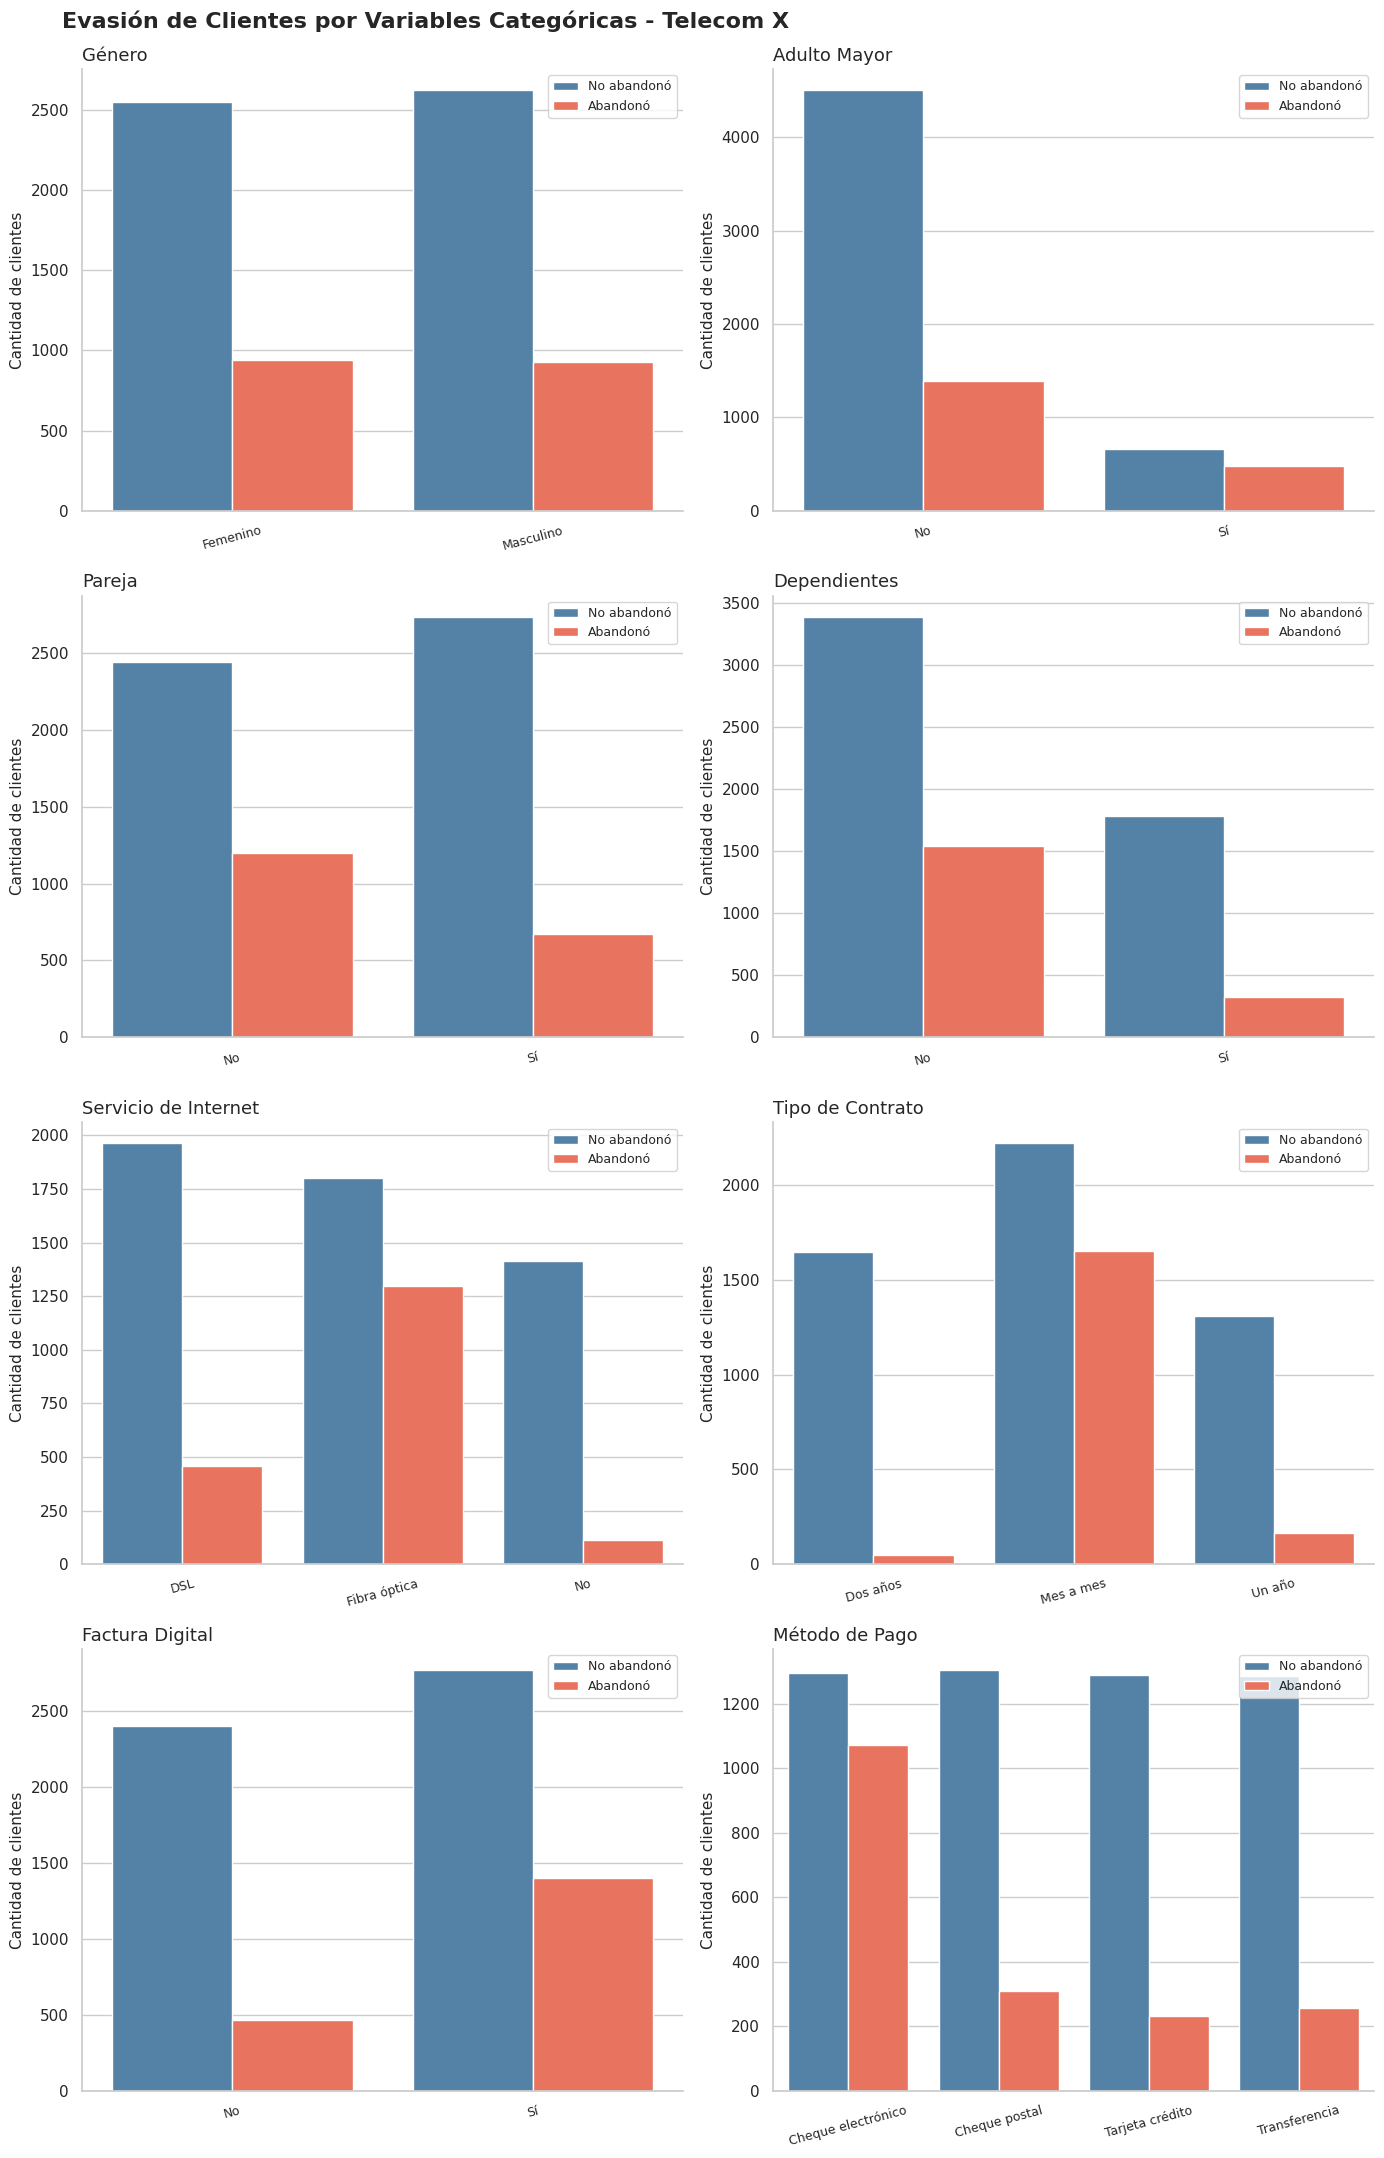

In [307]:
sns.set_theme(style='whitegrid')

# Mapeo de valores binarios a etiquetas legibles
mapeos = {
    'Genero'           : {0: 'Femenino', 1: 'Masculino'},
    'Adulto_Mayor'     : {0: 'No', 1: 'Sí'},
    'Pareja'           : {0: 'No', 1: 'Sí'},
    'Dependientes'     : {0: 'No', 1: 'Sí'},
    'Servicio_Internet': {'DSL': 'DSL', 'Fiber optic': 'Fibra óptica', 'No': 'No'},
    'Tipo_Contrato'    : {'Month-to-month': 'Mes a mes', 'One year': 'Un año', 'Two year': 'Dos años'},
    'Factura_Digital'  : {0: 'No', 1: 'Sí'},
    'Metodo_Pago'      : {
        'Bank transfer (automatic)' : 'Transferencia',
        'Credit card (automatic)'   : 'Tarjeta crédito',
        'Electronic check'          : 'Cheque electrónico',
        'Mailed check'              : 'Cheque postal'
    }
}

categoricas = {
    'Genero'           : 'Género',
    'Adulto_Mayor'     : 'Adulto Mayor',
    'Pareja'           : 'Pareja',
    'Dependientes'     : 'Dependientes',
    'Servicio_Internet': 'Servicio de Internet',
    'Tipo_Contrato'    : 'Tipo de Contrato',
    'Factura_Digital'  : 'Factura Digital',
    'Metodo_Pago'      : 'Método de Pago'
}

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.suptitle('Evasión de Clientes por Variables Categóricas - Telecom X\n',
             fontsize=16, fontweight='bold', x=0.05, ha='left')

for ax, (col, titulo) in zip(axes.ravel(), categoricas.items()):
    # Aplicar mapeo de etiquetas
    temp = datos_limpios[[col, 'Abandono']].copy()
    temp[col] = temp[col].map(mapeos[col])

    conteo = temp.groupby([col, 'Abandono']).size().reset_index(name='Cantidad')
    conteo['Estado'] = conteo['Abandono'].map({0: 'No abandonó', 1: 'Abandonó'})

    sns.barplot(data=conteo, x=col, y='Cantidad', hue='Estado',
                palette=['steelblue', 'tomato'], ax=ax, legend=True)

    ax.set_title(titulo, loc='left', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de clientes', fontsize=11)
    ax.xaxis.set_tick_params(labelsize=9, rotation=15)
    ax.legend(title='', fontsize=9)
    sns.despine()

plt.tight_layout()
plt.show()

## 📊 Distribución de Evasión por Variables Numéricas

Exploración de la distribución de las variables numéricas clave entre los clientes que cancelaron el servicio y los que permanecieron. Este análisis permite identificar si ciertos rangos de valores, como pocos meses de contrato o cargos elevados,
están más asociados con la evasión.

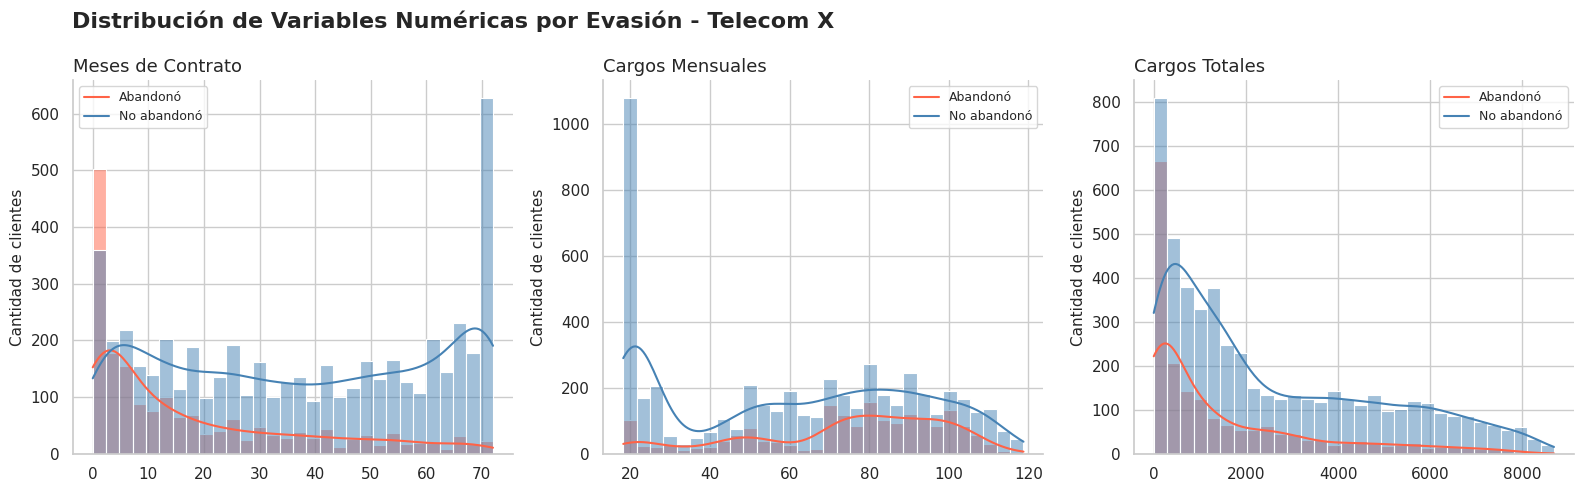

In [308]:
sns.set_theme(style='whitegrid')

numericas = {
    'Meses_Contrato' : 'Meses de Contrato',
    'Cargos_Mensuales': 'Cargos Mensuales',
    'Cargos_Totales'  : 'Cargos Totales'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Variables Numéricas por Evasión - Telecom X',
             fontsize=16, fontweight='bold', x=0.05, ha='left')

for ax, (col, titulo) in zip(axes, numericas.items()):
    sns.histplot(data=datos_limpios, x=col, hue='Abandono',
                 palette={0: 'steelblue', 1: 'tomato'},
                 kde=True, bins=30, ax=ax, legend=True)

    ax.set_title(titulo, loc='left', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad de clientes', fontsize=11)
    ax.legend(title='', labels=['Abandonó', 'No abandonó'], fontsize=9)
    sns.despine()

plt.tight_layout()
plt.show()

#📄Informe final

# 📄 Informe Final — Análisis de Evasión de Clientes | Telecom X

---

## 🔹 Introducción

Telecom X enfrenta una alta tasa de cancelaciones de clientes, fenómeno conocido como **Churn** o evasión.
Este informe presenta los resultados del análisis exploratorio de datos (EDA) realizado sobre una base de
7,267 registros de clientes, con el objetivo de identificar los factores asociados a la cancelación del servicio.

El análisis sigue el proceso **ETL (Extracción, Transformación y Carga)**:
- **Extracción**: datos obtenidos desde una API en formato JSON.
- **Transformación**: limpieza, normalización y estandarización de los datos.
- **Carga y Análisis**: visualizaciones y métricas para identificar patrones de evasión.

Los hallazgos de este informe servirán de base para que el equipo de Data Science desarrolle
modelos predictivos y estrategias de retención de clientes.

## 🔹 Limpieza y Tratamiento de Datos

Durante la etapa de transformación se identificaron y corrigieron los siguientes problemas:

| Problema detectado | Acción tomada |
|---|---|
| Columnas anidadas en formato JSON (`customer`, `phone`, `internet`, `account`) | Normalización con `pd.json_normalize()` |
| 224 registros con valor vacío `""` en columna `Churn` | Eliminación — representa solo el 3% del total y es la variable objetivo |
| `Charges.Total` en formato string en lugar de numérico | Conversión con `pd.to_numeric()` |
| 11 registros con `Charges.Total` nulo y `tenure = 0` | Imputación con valor `0` — clientes recién registrados sin cargos acumulados |
| Columnas categóricas con valores `Yes/No` | Conversión a binario (1/0) para facilitar el análisis |
| Columnas en inglés | Renombradas al español para mayor claridad |

Tras la limpieza, el dataset final quedó con **7,043 registros** y **22 columnas**.

## 🔹 Análisis Exploratorio de Datos

### Distribución general de la evasión

De los 7,043 clientes analizados, el **73.46% (5,174) permanecieron** en la empresa,
mientras que el **26.54% (1,869) cancelaron** el servicio. Este desbalance de clases
es importante a considerar en etapas posteriores de modelado predictivo.

### Métricas descriptivas de variables numéricas

| Variable | Media | Mediana | Std |
|---|---|---|---|
| Meses de Contrato | 32.4 | 29.0 | 24.6 |
| Cargos Mensuales | 64.76 | 70.35 | 30.09 |
| Cargos Totales | 2279.73 | 1394.55 | 2266.79 |

La alta diferencia entre la media y mediana de `Cargos Totales` ($2,279 vs $1,394)
refleja una distribución asimétrica positiva, con clientes de larga permanencia
acumulando cargos muy elevados.

### Variables numéricas y evasión

Los histogramas revelan tres patrones clave:
- **Meses de Contrato**: los clientes que abandonan se concentran fuertemente en los
  **primeros meses** (0-10 meses), mientras que los clientes fieles se distribuyen
  de forma más uniforme hasta los 72 meses.
- **Cargos Mensuales**: los clientes que abandonan presentan una mayor concentración
  en rangos de **cargos altos ($70-$100)**, sugiriendo sensibilidad al precio.
- **Cargos Totales**: los clientes que abandonan acumulan cargos totales bajos,
  consistente con su corta permanencia en la empresa.

### Variables categóricas y evasión

- **Tipo de Contrato**: es la variable con mayor poder discriminatorio. Los clientes
  con contrato **mes a mes** muestran una tasa de abandono proporcionalmente mucho
  mayor que los de contratos anuales o bianuales.
- **Servicio de Internet**: los clientes con **Fibra óptica** presentan una tasa de
  evasión considerablemente más alta que los de DSL o sin internet.
- **Adulto Mayor**: los clientes adultos mayores (≥65 años) tienen una proporción
  de abandono más elevada en relación a su tamaño de grupo.
- **Dependientes y Pareja**: clientes sin dependientes ni pareja tienden a abandonar
  más, posiblemente por menor vínculo con el servicio.
- **Método de Pago**: el **cheque electrónico** concentra la mayor cantidad de
  clientes que abandonaron, destacándose sobre los métodos automáticos.
- **Género**: no muestra diferencias significativas entre hombres y mujeres.

## 🔹 Conclusiones e Insights

1. **La permanencia es el factor más crítico**: la mayoría de las cancelaciones ocurren
   en los primeros meses. Si un cliente supera los 12 meses de contrato, la probabilidad
   de que abandone disminuye considerablemente.

2. **El tipo de contrato es determinante**: los contratos mes a mes presentan la tasa
   de evasión más alta. Los clientes con contratos anuales o bianuales son
   significativamente más leales.

3. **La fibra óptica tiene un problema de retención**: a pesar de ser el servicio de
   mayor valor, concentra una alta proporción de abandonos, lo que puede indicar
   insatisfacción con la calidad o percepción de precio elevado.

4. **El cheque electrónico está asociado a mayor evasión**: los clientes que pagan
   de forma manual (no automática) tienen mayor tendencia a cancelar, posiblemente
   por fricción en el proceso de pago o menor compromiso con el servicio.

5. **Clientes sin red de soporte social abandonan más**: la ausencia de pareja o
   dependientes se correlaciona con mayor evasión, sugiriendo que los planes
   familiares o compartidos generan mayor retención.

## 🔹 Recomendaciones Estratégicas

| Área | Recomendación |
|---|---|
| **Contratos** | Ofrecer incentivos (descuentos, beneficios) para migrar clientes de contrato mes a mes a contratos anuales o bianuales. |
| **Primeros meses** | Implementar un programa de onboarding activo durante los primeros 3 meses, periodo crítico de mayor abandono. |
| **Fibra óptica** | Investigar la satisfacción de clientes con fibra óptica — evaluar si el problema es precio, calidad o soporte técnico. |
| **Método de pago** | Incentivar la migración hacia métodos de pago automáticos (débito o tarjeta), reduciendo la fricción y el riesgo de cancelación. |
| **Adultos mayores** | Diseñar planes específicos con soporte técnico prioritario y precios accesibles para este segmento vulnerable. |
| **Modelos predictivos** | Usar las variables `Meses_Contrato`, `Tipo_Contrato`, `Servicio_Internet` y `Metodo_Pago` como features principales en modelos de predicción de churn. |

---
*Informe elaborado como parte del proyecto "Churn de Clientes" — Telecom X*
*Herramientas utilizadas: Python, Pandas, Matplotlib, Seaborn*